## Practica 5: latent space of the Auto-Encoder
### In this practice, you will use the image sample MNIST, which is composed of numbers. This famous library is directly included inside the tensorflow package :

In [1]:
import tensorflow as tf
#from tensorflow import kerasi
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
import numpy as np
mnist = keras.datasets.mnist

### You will generate an autoencoder that allows to reproduce the images with a pretty good fidelity before analysing the latent layer in order to extract the information to classify these numbers. This study will be done at different levels:
* Direct k-means 
* GMM

## 1 Exercise: Construct and train your Auto-Encoder
### 1.1 Generation of training set and validation set

In [2]:
# Read the data from MNIST and separate the whole sample into 3 as follows:
# 1. 55000 for the training set
# 2. 10000 for the validation set
# 3. 5000 for the test set

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Combine train and test to have all 70,000 samples
x_all = np.concatenate((x_train, x_test))
y_all = np.concatenate((y_train, y_test))

# Split into train (55000), validation (10000), and test (5000)
x_train, y_train = x_all[:55000], y_all[:55000]
x_val, y_val = x_all[55000:65000], y_all[55000:65000]
x_test, y_test = x_all[65000:70000], y_all[65000:70000]

print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(55000, 28, 28) (55000,)
(10000, 28, 28) (10000,)
(5000, 28, 28) (5000,)


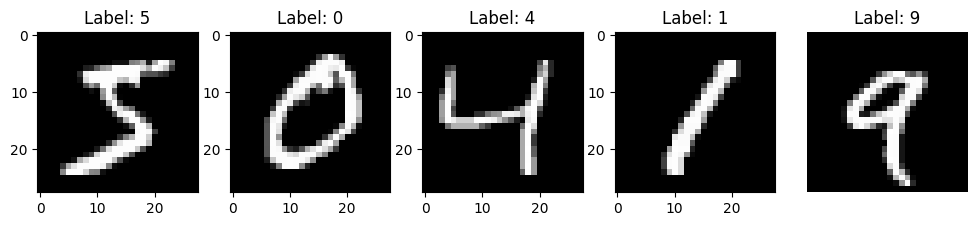

In [3]:
plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
plt.axis('off')
plt.show()  

#### Here "x_train" constains the images and "y_train" contains the labels of these images. The same applies for the validation and test sets. You can see that the images are in grayscale and have a size of 28x28 pixels. The labels are integers from 0 to 9, representing the digit in the image. The test set will be important for this practice for evaluating the performance of your classification after using the validation for constructing your classifier.
* In order to help your training, we recommend that you normalize the pictures pixel values between 0 and 1.
* Also, no forget to use the "flatten()" method in order to transform the (28,28) shape into (1, 764) You can use a latent layer with 20 neurons as a suggestion.
* Your goal will be to reach at least 1% on the validation set loss function using a mean squared error or mean
absolute error.
#### For this stage:
1) Explain your choice of architecture, and activation functions.
2) Plot the loss function evolution.
3) Using your autoencoder, encode the validation set that you will save in a variable "encoded_imgs".
4) Chose 10 examples from "encoded_imgs" that you will decode using your autoencoder.
5) Using the "imshow()" function, plot the decoded images obtained comparing them to the original images.


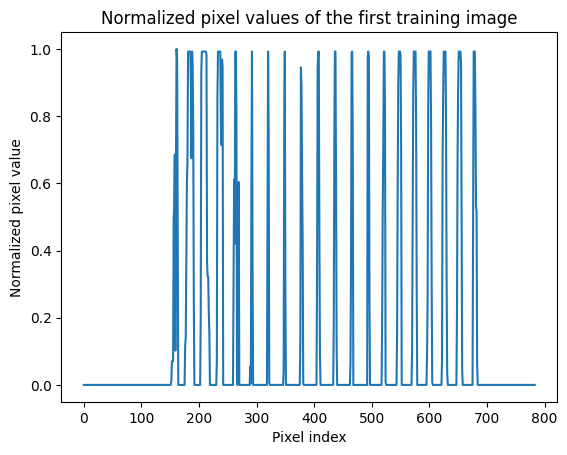

In [4]:
# First,let's normalize the data to be in the range [0, 1] and reshape it to fit the input of the autoencoder.

x_train_norm = MinMaxScaler().fit_transform(x_train.reshape(-1, 28*28))
x_val_norm = MinMaxScaler().fit_transform(x_val.reshape(-1, 28*28))
x_test_norm = MinMaxScaler().fit_transform(x_test.reshape(-1, 28*28))

plt.plot(x_train_norm[0])
plt.title("Normalized pixel values of the first training image")
plt.xlabel("Pixel index")
plt.ylabel("Normalized pixel value")
plt.show()

In [5]:
# Now we flatten the images to be in the shape (1, 784) for the autoencoder input.

x_train_flat = x_train_norm.reshape((len(x_train_norm), 28*28))
x_val_flat = x_val_norm.reshape((len(x_val_norm), 28*28))
x_test_flat = x_test_norm.reshape((len(x_test_norm), 28*28))


print(x_train_flat.shape)
print(x_val_flat.shape)
print(x_test_flat.shape)


(55000, 784)
(10000, 784)
(5000, 784)


In [6]:
# Encoder architecture
input_img = keras.Input(shape=(784,))
encoded = keras.layers.Dense(128, activation='relu')(input_img)
encoded = keras.layers.Dense(64, activation='relu')(encoded)
encoded = keras.layers.Dense(32, activation='relu')(encoded)
encoded = keras.layers.Dense(20, activation='relu')(encoded)

# Decoder architecture  
decoded = keras.layers.Dense(32, activation='relu')(encoded)
decoded = keras.layers.Dense(64, activation='relu')(decoded)
decoded = keras.layers.Dense(128, activation='relu')(decoded)
decoded = keras.layers.Dense(784, activation='sigmoid')(decoded)
# Autoencoder model
autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mean_squared_error')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 20)             │           660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 223,716 (873.89 KB)

 Trainable params: 223,716 (873.89 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Callback with 50 epochs and early stopping with patience of 5 epochs
early_stopping = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
                   keras.callbacks.ReduceLROnPlateau(factor=0.4, patience=10, min_lr=1e-8)]


In [ ]:
# run the training
history = autoencoder.fit(x_train_flat, x_train_flat,
                epochs=120,
                batch_size=128,
                shuffle=True,
                validation_data=(x_val_flat, x_val_flat),
                callbacks=early_stopping)

Epoch 1/120
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0820 - val_loss: 0.0362 - learning_rate: 0.0010
Epoch 2/120
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0341 - val_loss: 0.0284 - learning_rate: 0.0010
Epoch 3/120
430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0271 - val_loss: 0.0240 - learning_rate: 0.0010
Epoch 4/120
210/430 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0237

Percent of the validation loss  0.8412095718085766 %


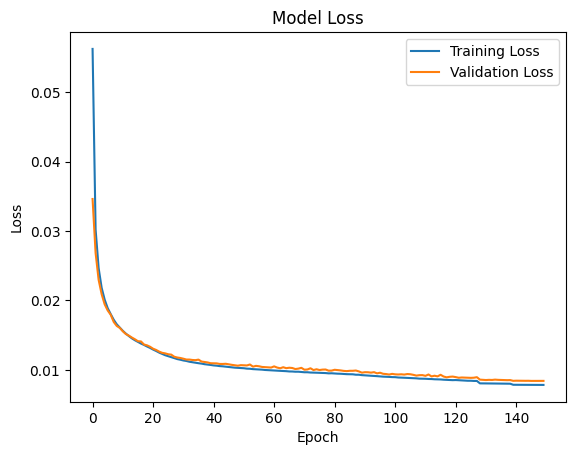

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
print("Percent of the validation loss ", 100 * min(history.history['val_loss']), "%")
plt.show()

In [ ]:
# 3) using your autoencoder, encode the validation set that you will save in a variable "encoded_imgs"
encoder = keras.Model(input_img, encoded)
encoded_imgs = encoder.predict(x_val_flat,verbose=1)

print(f"Original validation set shape: {x_val.shape}")
print(f"Encoded validation set shape: {encoded_imgs.shape}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 306us/step
Original validation set shape: (10000, 28, 28)
Encoded validation set shape: (10000, 20)


In [ ]:
# We choose 10 encoded images to visualize the results. We will use the decoder part of the autoencoder to reconstruct the original images from the encoded representations.
# Create a decoder model
decoder_input = keras.Input(shape=(20,))
decoder_output = decoded  

decoder = keras.Model(autoencoder.layers[4].input, autoencoder.layers[-1].output)

In [ ]:
# Visualization
num_images = 10
reconstructed_imgs = decoder.predict(encoded_imgs[:num_images], verbose=1)
plt.figure(figsize=(20, 4))
for i in range(num_images):
    # Original image
    ax = plt.subplot(2, num_images, i + 1)
    plt.imshow(x_val[i].reshape(28, 28), cmap='gray')
    plt.title(f"Original: {y_val[i]}")
    plt.axis('off')

    # Reconstructed image
    ax = plt.subplot(2, num_images, i + 1 + num_images)
    plt.imshow(reconstructed_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.show()

NameError: name 'decoder' is not defined